In [ ]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, Flatten, Input
from tensorflow.keras.models import Sequential
import pandas as pd
from IPython.display import FileLink, display
import os
from copy import deepcopy
from tensorflow.keras.layers import Dense


In [26]:
def laplacian_filter(image, **kwargs):
    ddepth = kwargs.get("ddepth", cv2.CV_64F)
    ksize = kwargs.get("ksize", 1)  # Must be 1,3,5,7
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # type: ignore[arg-type]
    lap = cv2.Laplacian(gray, ddepth=ddepth, ksize=ksize)
    abs_lap = np.uint8(np.clip(np.absolute(lap), 0, 255))
    return cv2.cvtColor(abs_lap, cv2.COLOR_GRAY2BGR)  # type: ignore[arg-type]

def blur_filter(image, **kwargs):
    ksize = kwargs.get('ksize', (5,5))
    return cv2.blur(image, ksize)

def gaussian_blur_filter(image, **kwargs):
    ksize = kwargs.get('ksize', (5,5))
    sigmaX = kwargs.get('sigmaX', 0)
    sigmaY = kwargs.get('sigmaY', 0)
    return cv2.GaussianBlur(image, ksize, sigmaX, sigmaY)

def sharpen_filter(image, **kwargs):
    kernel = kwargs.get("kernel", None)
    ksize = kwargs.get("ksize", 3)
    strength = kwargs.get("strength", 5)
    if kernel is None:
        if ksize % 2 == 0:
            raise ValueError("ksize must be odd")
        kernel = -1 * np.ones((ksize, ksize), dtype=np.float32)
        center = ksize // 2
        kernel[center, center] = strength + (ksize * ksize - 1)
    return cv2.filter2D(image, ddepth=-1, kernel=kernel)

def add_gaussian_noise(image, **kwargs):
    mean = kwargs.get("mean", 0)
    std_dev = kwargs.get("std_dev", 25)
    image_float = image.astype(np.float64)
    noise = np.random.normal(mean, std_dev, image_float.shape)
    noisy_image = image_float + noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
    return noisy_image

def add_salt_noise(image, **kwargs):
    output = image.copy()
    if len(output.shape) == 2:
        row, col = output.shape
    else:
        row, col, _ = output.shape
    amount = kwargs.get("amount", 0.01)
    seed = kwargs.get("seed", None)
    if seed is not None:
        random.seed(int(seed))
        np.random.seed(int(seed))
    num_pixels = int(amount * row * col)
    for _ in range(num_pixels):
        y = random.randint(0, row-1)
        x = random.randint(0, col-1)
        output[y, x] = 255
    return output

def add_pepper_noise(image, **kwargs):
    amount = kwargs.get("amount", 0.01)
    seed = kwargs.get("seed", None)
    if seed is not None:
        random.seed(int(seed))
        np.random.seed(int(seed))
    output = image.copy()
    if len(output.shape) == 2:
        row, col = output.shape
    else:
        row, col, _ = output.shape
    num_pixels = int(amount * row * col)
    for _ in range(num_pixels):
        y = random.randint(0, row-1)
        x = random.randint(0, col-1)
        output[y, x] = 0
    return output

def edge_detection_filter(image, **kwargs):
    ksize = kwargs.get("ksize", 3)
    dx = kwargs.get("dx", 1)
    dy = kwargs.get("dy", 1)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # type: ignore[arg-type]
    sobelxy = cv2.Sobel(src=gray, ddepth=cv2.CV_64F, dx=dx, dy=dy, ksize=ksize)
    sobelxy_abs = np.uint8(np.clip(np.absolute(sobelxy), 0, 255))
    return cv2.cvtColor(sobelxy_abs, cv2.COLOR_GRAY2BGR)  # type: ignore[arg-type]

def apply_noise_filter(image, noise_type, **kwargs):
    noise_type = noise_type.lower()
    if noise_type == "gaussian":
        noisy_img = add_gaussian_noise(image, **kwargs)
    elif noise_type == "salt":
        noisy_img = add_salt_noise(image, **kwargs)
    elif noise_type == "pepper":
        noisy_img = add_pepper_noise(image, **kwargs)
    elif noise_type == "blur":
        noisy_img = blur_filter(image, **kwargs)
    elif noise_type == "gaussianb":
        noisy_img = gaussian_blur_filter(image, **kwargs)
    elif noise_type == "laplacian":
        noisy_img = laplacian_filter(image, **kwargs)
    elif noise_type == "sharpen":
        noisy_img = sharpen_filter(image, **kwargs)
    elif noise_type == "edge":
        noisy_img = edge_detection_filter(image, **kwargs)
    else:
        raise ValueError(f"Unknown filter type: {noise_type}")

    # convert to 2D grayscale
    if len(noisy_img.shape) == 3:
        if noisy_img.shape[2] == 3 or noisy_img.shape[2] == 4:
            noisy_img = cv2.cvtColor(noisy_img, cv2.COLOR_BGR2GRAY)  # type: ignore[arg-type]
        else:
            noisy_img = noisy_img[..., 0]

    if noisy_img.shape != (28, 28):
        noisy_img = cv2.resize(noisy_img, (28, 28))  # type: ignore[arg-type]
    return noisy_img

In [27]:
def infer_test_param_dict(noise_type, test_param):
    if isinstance(test_param, dict):
        return test_param
    elif isinstance(test_param, (int, float)):
        if noise_type.lower() == "gaussian":
            return {"std_dev": test_param}
        elif noise_type.lower() in {"salt", "pepper"}:
            return {"amount": test_param}
        elif noise_type.lower() in {"blur", "gaussianb", "sharpen", "laplacian"}:
            return {"ksize": test_param}
        else:
            raise ValueError(f"Cannot infer parameter for noise type '{noise_type}' from numeric value: {test_param}")
    else:
        raise ValueError(f"Unsupported test_param format: {test_param}")

In [28]:
class ThresholdedTrainableReLU(Layer):
    def __init__(self, initial_slope=1.0, initial_threshold=0.0, **kwargs):
        super().__init__(**kwargs)
        self.initial_slope = initial_slope
        self.initial_threshold = initial_threshold

    def build(self, input_shape):
        self.threshold = self.add_weight(
            shape=(1,), initializer=tf.keras.initializers.Constant(self.initial_threshold),
            trainable=True, name="threshold")
        self.slope = self.add_weight(
            shape=(1,), initializer=tf.keras.initializers.Constant(self.initial_slope),
            trainable=True, name="slope")

    def call(self, inputs):
        return self.slope * tf.nn.relu(inputs - self.threshold)

    def get_config(self):
        config = super().get_config()
        config.update({
            "initial_slope": self.initial_slope,
            "initial_threshold": self.initial_threshold
        })
        return config

In [29]:
def sample_noise_params(noise_type):
    noise_type = noise_type.lower()
    if noise_type in ['blur', 'gaussianb']:
        k = random.choice([1,3,5,7,9])
        if noise_type == 'gaussianb':
            sigma = random.uniform(0.5, 3.0)
            return {'ksize': (k,k), 'sigmaX': sigma, 'sigmaY': sigma}
        else:
            return {'ksize': (k,k)}
    elif noise_type == 'laplacian':
        k = random.choice([1,3,5,7])
        return {'ksize': k}
    elif noise_type == 'sharpen':
        k = random.choice([1,3,5,7,9])
        return {'ksize': k}
    elif noise_type in ['salt', 'pepper']:
        amount = random.uniform(0.01, 0.1)
        return {'amount': amount}
    elif noise_type == 'gaussian':
        std_dev = random.uniform(0, 200)
        return {'mean': 0, 'std_dev': std_dev}
    else:
        return {}


In [30]:
lr_log = []
def custom_lr_scheduler(epoch, lr):
    if epoch < 5:
        lr = lr + 0.0005
    elif epoch % 10 == 0:
        lr = lr * 0.8
    lr_log.append(lr)
    return lr

In [ ]:
class DelayedEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, base_callback, start_epoch=20):
        super().__init__()
        self.base_callback = base_callback
        self.start_epoch = start_epoch
        self.stopped_epoch = None  

    def set_model(self, model):
        self.base_callback.set_model(model)

    def set_params(self, params):
        self.base_callback.set_params(params)

    def on_train_begin(self, logs=None):
        self.base_callback.on_train_begin(logs)

    def on_epoch_end(self, epoch, logs=None):
        if epoch == self.start_epoch:
            print(f"[DelayedEarlyStopping] EarlyStopping active from epoch {epoch}")
        if epoch >= self.start_epoch:
            self.base_callback.on_epoch_end(epoch, logs)

            # Check if base callback stopped training
            if hasattr(self.base_callback, "stopped_epoch") and self.base_callback.stopped_epoch > 0:
                self.stopped_epoch = self.base_callback.stopped_epoch

In [49]:
def build_model(threshold1=0.0, slope1=1.0, threshold2=0.0, slope2=1.0):
    model = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation=None, name='dense1'),
        ThresholdedTrainableReLU(initial_threshold=threshold1, initial_slope=slope1),
        Dense(64, activation=None, name='dense2'),
        ThresholdedTrainableReLU(initial_threshold=threshold2, initial_slope=slope2),
        Dense(10, activation='softmax', name='output')
    ])
    return model


def clip_and_normalize(images):
    images = np.clip(images, 0, 255)
    return images.astype("float32") / 255.0

In [50]:
def print_model_weights(model):
    print("Model weights and biases (Dense layers):")
    for layer in model.layers:
        if isinstance(layer, Dense):
            weights, biases = layer.get_weights()
            print(f"{layer.name} weights shape: {weights.shape}, biases shape: {biases.shape}")
            print(f"Sample weights (first 5): {weights.flatten()[:5]}")
            print(f"Sample biases (first 5): {biases[:5]}")


In [34]:
def plot_training_history_static(history):
    acc = history.history['accuracy']
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history['loss']
    val_loss = history.history.get('val_loss', [])
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b-o', label='Training Accuracy')
    if val_acc:
        plt.plot(epochs, val_acc, 'g-o', label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b-o', label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'g-o', label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [35]:
def plot_learning_rate_static(lr_log):
    plt.figure(figsize=(6,4))
    plt.plot(range(1, len(lr_log)+1), lr_log, marker='o', color='purple')
    plt.title('Learning Rate per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [36]:
class ThresholdSlopeLogger(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.epoch_logs = {
            "threshold1": [],
            "slope1": [],
            "threshold2": [],
            "slope2": []
        }

    def on_epoch_end(self, epoch, logs=None):
        thresholds = [None, None]
        slopes = [None, None]
        idx = 0
        for layer in self.model.layers:  # self.model is automatically set
            if isinstance(layer, ThresholdedTrainableReLU):
                thresholds[idx] = layer.threshold.numpy()[0]
                slopes[idx] = layer.slope.numpy()[0]
                idx += 1
                if idx >= 2:
                    break

        self.epoch_logs["threshold1"].append(thresholds[0])
        self.epoch_logs["slope1"].append(slopes[0])
        self.epoch_logs["threshold2"].append(thresholds[1])
        self.epoch_logs["slope2"].append(slopes[1])

In [37]:
def plot_threshold_slope(logger_callback, prefix="run"):
    epochs = range(1, len(logger_callback.epoch_logs["threshold1"]) + 1)

    # Plot threshold values
    plt.figure()
    plt.plot(epochs, logger_callback.epoch_logs["threshold1"], 'r-o', label="Threshold 1")
    plt.plot(epochs, logger_callback.epoch_logs["threshold2"], 'b-o', label="Threshold 2")
    plt.title("Thresholds over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Threshold Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{prefix}_thresholds.png")
    plt.close()

    # Plot slope values
    plt.figure()
    plt.plot(epochs, logger_callback.epoch_logs["slope1"], 'r-o', label="Slope 1")
    plt.plot(epochs, logger_callback.epoch_logs["slope2"], 'b-o', label="Slope 2")
    plt.title("Slopes over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Slope Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{prefix}_slopes.png")
    plt.close()

    print(f"Saved threshold/slope plots as {prefix}_thresholds.png and {prefix}_slopes.png")

In [38]:
def load_model_with_custom_relu_and_frozen_dense(weights_path, thresh1, slope1, thresh2, slope2):
    model = build_model(threshold1=thresh1, slope1=slope1, threshold2=thresh2, slope2=slope2)
    model.load_weights(weights_path)

    # Overwrite ReLU trainable weights (threshold and slope) with desired values
    relu_layers = [layer for layer in model.layers if isinstance(layer, ThresholdedTrainableReLU)]
    if len(relu_layers) >= 2:
        relu_layers[0].threshold.assign([thresh1])
        relu_layers[0].slope.assign([slope1])
        relu_layers[1].threshold.assign([thresh2])
        relu_layers[1].slope.assign([slope2])

    # Freeze Dense layers weights and biases
    for layer in model.layers:
        if isinstance(layer, Dense):
            layer.trainable = False

    return model


In [39]:
def show_summary_table(model, history, test_images, test_labels, noise_type, noise_kwargs, early_stop_callback,
                       threshold1, slope1, threshold2, slope2):
    # Evaluate test
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)

    result = {
        "Noise Type": noise_type,
        **{f"Noise Param: {key}": val for key, val in noise_kwargs.items()},
        "Train Loss": history.history['loss'][-1],
        "Validation Loss": history.history['val_loss'][-1],
        "Train Accuracy": history.history['accuracy'][-1],
        "Validation Accuracy": history.history['val_accuracy'][-1],
        "Test Loss": test_loss,
        "Test Accuracy": test_acc,
        "Epochs Run": len(history.history['loss']),
        "Optimizer": "Adam",  # You can parameterize this if needed
        "Initial LR": "0.001 (example)",  # Replace with your actual initial LR if you track it
        "LR Scheduler": "Custom (warmup + decay every 10 epochs)",  # Update if needed
        "Batch Size": 32,  # Hardcoded or param
        "Hidden Layers": ", ".join([str(layer.output.shape) for layer in model.layers if isinstance(layer, Dense)]),
        "Activation Functions": "ReLU (hidden), Softmax (output)",  # Update if dynamic
        "Early Stop Patience": early_stop_callback.patience if hasattr(early_stop_callback, 'patience') else None,
        "Stopped Epoch": getattr(early_stop_callback, "stopped_epoch", None),
        "threshold1": threshold1,
        "slope1": slope1,
        "threshold2": threshold2,
        "slope2": slope2,
    }

    # Add weights/bias shapes per Dense layer
    for layer in model.layers:
        if isinstance(layer, Dense):
            weights, biases = layer.get_weights()
            result[f"{layer.name} weights shape"] = str(weights.shape)
            result[f"{layer.name} biases shape"] = str(biases.shape)

    return result

In [40]:
def train_clean_then_test_noise(
    noise_type,
    test_params_list,
    epochs=50,
    patience=20,
    validation_split=0.1,
    csv_save_path="clean_train_test_noise.csv",
    weights_save_path="clean_mnist.weights.h5",
    threshold1=0.0,
    slope1=1.0,
    threshold2=0.0,
    slope2=1.0
):
    (train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
    train_images = np.squeeze(train_images).astype("uint8")
    test_images = np.squeeze(test_images).astype("uint8")

    experiment_results = []

    # Normalize clean train images to [0,1] float32
    clean_train = np.expand_dims(train_images, axis=-1).astype("float32") / 255.0

    for test_param in test_params_list:
        print(f"\n--- Training CLEAN model with test noise param: {test_param} ---")
        tf.keras.backend.clear_session()

        global lr_log
        lr_log = []

        # Build fresh model each iteration
        model = build_model(threshold1=threshold1, slope1=slope1, threshold2=threshold2, slope2=slope2)
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get noise param dict for this test_param
        test_param_dict = infer_test_param_dict(noise_type, test_param)
        if noise_type.lower() in {"salt", "pepper"}:
            amount = test_param_dict.get("amount", 0)
            if amount > 1.0:
                amount = amount / 100.0  # scale to fraction if needed
                test_param_dict["amount"] = amount
                print(f"Scaled salt/pepper amount to {amount}")

        # Create noisy test images with noise added on uint8 [0-255], clipped,
        # then normalized to float32 [0,1] with channel dim added
        noisy_test = []
        for img in test_images:
            if noise_type.lower() in {"laplacian", "edge"}:
                img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
                noisy_img = apply_noise_filter(img_bgr, noise_type, **test_param_dict)
                noisy_img = cv2.cvtColor(noisy_img, cv2.COLOR_BGR2GRAY)
            else:
                noisy_img = apply_noise_filter(img, noise_type, **test_param_dict)

            # Ensure clipped 0-255 uint8
            noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

            # Normalize to [0,1] float32 for model input
            noisy_img = noisy_img.astype(np.float32) / 255.0

            # Add channel dim for model (28,28,1)
            if noisy_img.ndim == 2:
                noisy_img = np.expand_dims(noisy_img, axis=-1)

            noisy_test.append(noisy_img)

        noisy_test = np.array(noisy_test)

        # Visualize some samples for sanity check
        num_samples = 5
        plt.figure(figsize=(num_samples * 3, 6))
        for i in range(num_samples):
            plt.subplot(2, num_samples, i + 1)
            plt.imshow(test_images[i], cmap='gray')
            plt.title("Clean")
            plt.axis('off')
            plt.subplot(2, num_samples, i + 1 + num_samples)
            plt.imshow(noisy_test[i].squeeze(), cmap='gray')
            plt.title(f"Noisy {noise_type}\nparam={test_param}")
            plt.axis('off')
        plt.tight_layout()
        plt.show()

        print(f"Noisy test pixel stats: min={noisy_test.min()}, max={noisy_test.max()}, mean={noisy_test.mean()}")

        # Callbacks
        early_stop_base = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=patience, restore_best_weights=True)
        early_stop_callback = DelayedEarlyStopping(base_callback=early_stop_base, start_epoch=0)
        lr_callback = tf.keras.callbacks.LearningRateScheduler(custom_lr_scheduler)
        threshold_logger = ThresholdSlopeLogger()


        # Train on clean data
        history = model.fit(clean_train, train_labels,
                            validation_split=validation_split,
                            epochs=epochs,
                            batch_size=32,
                            callbacks=[lr_callback, early_stop_callback, threshold_logger],
                            verbose=1)

        # Save weights once after training
        model.save_weights(weights_save_path)
        print(f"Saved clean trained model weights to: {weights_save_path}")

        # Evaluate on noisy test data
        test_loss, test_acc = model.evaluate(noisy_test, test_labels, verbose=1)
        print(f"Test accuracy on noisy ({noise_type}) data with params {test_param_dict}: {test_acc*100:.2f}%")

        result = show_summary_table(
            model=model,
            history=history,
            test_images=noisy_test,
            test_labels=test_labels,
            noise_type=noise_type + "_test",
            noise_kwargs={"test_param": test_param},
            early_stop_callback=early_stop_callback,
            threshold1=threshold1,
            slope1=slope1,
            threshold2=threshold2,
            slope2=slope2,
        )

        print("Run summary:", result)
        experiment_results.append(result)

        plot_training_history_static(history)
        plot_learning_rate_static(lr_log)
        plot_threshold_slope(threshold_logger, prefix="clean")

    # Save all experiment results to CSV
    df = pd.DataFrame(experiment_results)
    df.to_csv(csv_save_path, index=False)
    print(f"\nSaved clean training experiment results to '{csv_save_path}'")
    display(FileLink(csv_save_path))

    return weights_save_path, experiment_results

In [41]:
def preprocess_noisy_mnist_batch(x_batch, noise_type, **kwargs):
    result = []
    for img in x_batch:
        img_uint8 = (img * 255).astype(np.uint8)
        noisy = apply_noise_filter(img_uint8, noise_type, **kwargs)
        noisy = noisy.astype(np.float32) / 255.0
        noisy = np.expand_dims(noisy, -1)
        result.append(noisy)
    return np.array(result)

In [53]:
def train_noisy_with_loaded_weights_custom_relu(
    noise_types,
    sample_params_func,
    test_params_list,
    weights_path,
    threshold1, slope1,
    threshold2, slope2,
    epochs=50,
    patience=10,
    validation_split=0.1,
    csv_save_path="noisy_train_test_noise.csv"
):
    tf.keras.backend.clear_session()

    (train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
    train_images = train_images.astype("uint8")
    test_images = test_images.astype("uint8")

    experiment_results = []

    if isinstance(noise_types, str):
        noise_types = [noise_types]

    for noise_type in noise_types:
        for test_param in test_params_list:
            print(f"\n=== Noise Type: {noise_type} | Test Param: {test_param} ===")

            # Use the helper to get model with clean weights + desired ReLU params + frozen Dense
            model = load_model_with_custom_relu_and_frozen_dense(
                weights_path, threshold1, slope1, threshold2, slope2
            )

            model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

            print("\nTrainable variables:")
            for var in model.trainable_variables:
                print(f"  {var.name} shape={var.shape}")

            # Prepare noisy training data
            noisy_train = np.array([
                apply_noise_filter(img, noise_type, **sample_params_func(noise_type))
                for img in train_images
            ])
            noisy_train = clip_and_normalize(noisy_train)

            test_param_dict = infer_test_param_dict(noise_type, test_param)
            noisy_test = np.array([
                apply_noise_filter(img, noise_type, **test_param_dict)
                for img in test_images
            ])
            noisy_test = clip_and_normalize(noisy_test)

            # Sanity check with clean model
            clean_model = build_model(0.0, 1.0, 0.0, 1.0)
            clean_model.load_weights(weights_path)
            clean_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

            print("\nSanity check: Clean model on clean test")
            clean_model.evaluate(test_images.astype("float32") / 255.0, test_labels, verbose=2)
            print("\nSanity check: Clean model on noisy test")
            clean_model.evaluate(noisy_test, test_labels, verbose=2)

            # Callbacks
            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1
            )
            lr_callback = tf.keras.callbacks.LearningRateScheduler(custom_lr_scheduler)
            threshold_logger = ThresholdSlopeLogger()

            history = model.fit(
                noisy_train, train_labels,
                validation_split=validation_split,
                epochs=epochs,
                batch_size=32,
                callbacks=[lr_callback, early_stop, threshold_logger],
                verbose=1
            )

            print_model_weights(model)

            # Evaluate final fine-tuned model on noisy test set// the actual testing noise 
            
            test_loss, test_acc = model.evaluate(noisy_test, test_labels, verbose=1)
            print(f"Final test accuracy on noisy ({noise_type}) data with params {test_param_dict}: {test_acc*100:.2f}%")

            result = show_summary_table(
                model=model,
                history=history,
                test_images=noisy_test,
                test_labels=test_labels,
                noise_type=noise_type + "_test",
                noise_kwargs={"test_param": test_param},
                early_stop_callback=early_stop,
                threshold1=threshold1,
                slope1=slope1,
                threshold2=threshold2,
                slope2=slope2
            )
            experiment_results.append(result)

            plot_training_history_static(history)
            plot_learning_rate_static(lr_log)
            plot_threshold_slope(threshold_logger, prefix=noise_type)

    df = pd.DataFrame(experiment_results)
    df.to_csv(csv_save_path, index=False)
    print(f"\nSaved experiment results to '{csv_save_path}'")
    display(FileLink(csv_save_path))

    return experiment_results


--- Training CLEAN model with test noise param: {'mean': 0, 'std_dev': 0} ---


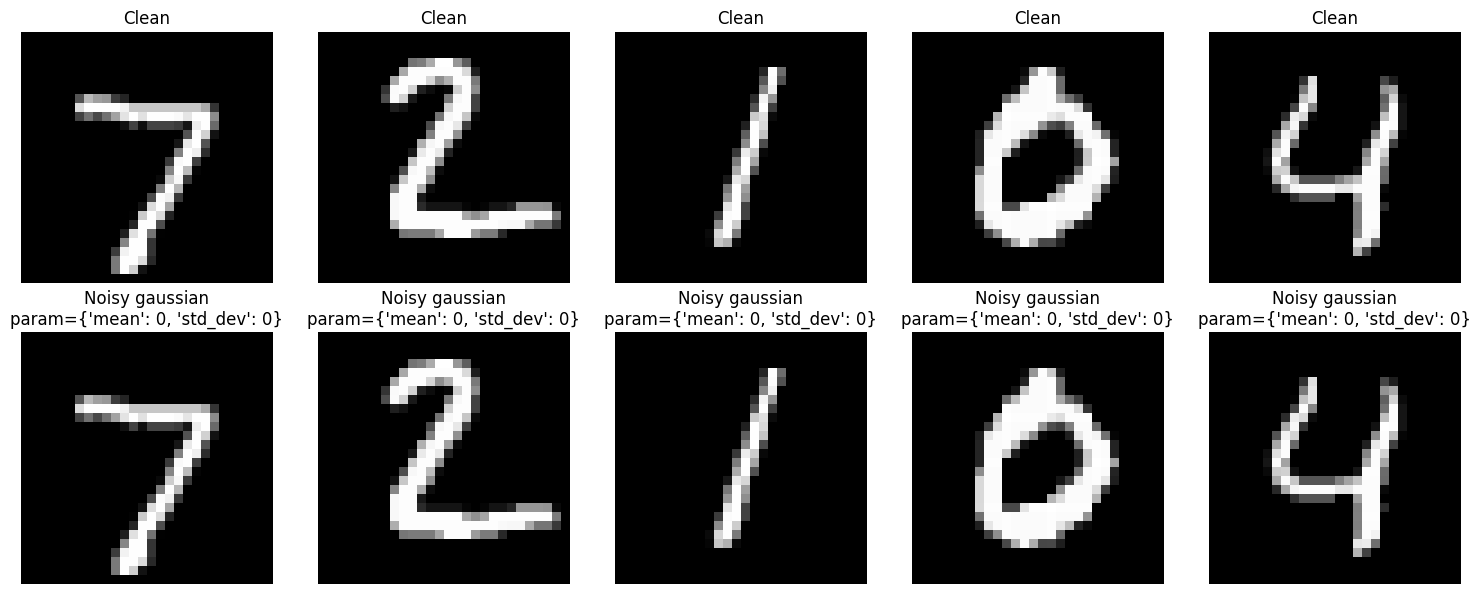

Noisy test pixel stats: min=0.0, max=1.0, mean=0.13251467049121857
Epoch 1/500
 839/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8400 - loss: 0.5373

In [ ]:
# Clean training first - save weights
weights_path, clean_results = train_clean_then_test_noise(
    noise_type='gaussian',
    test_params_list=[
        {"mean": 0, "std_dev": 0},
        {"mean": 0, "std_dev": 50},
        {"mean": 0, "std_dev": 100},
        {"mean": 0, "std_dev": 150},
        {"mean": 0, "std_dev": 200}
    ],
    epochs=500,
    patience=20,
    csv_save_path="clean_train_test_noise.csv",
    weights_save_path="clean_mnist.weights.h5",
    threshold1=0.0,
    slope1=1.0,
    threshold2=0.0,
    slope2=1.0
)

# Another experiment, same weights, different threshold/slope:
noisy_results_5 = train_noisy_with_loaded_weights_custom_relu(
    noise_types='gaussian',
    sample_params_func=sample_noise_params,
    test_params_list=[
        {"mean": 0, "std_dev": 0},
        {"mean": 0, "std_dev": 50},
        {"mean": 0, "std_dev": 100},
        {"mean": 0, "std_dev": 150},
        {"mean": 0, "std_dev": 200}
    ],
    weights_path=weights_path,
    threshold1=0.0,
    slope1=1.0,
    threshold2=0.0,
    slope2=1.0,
    epochs=500,
    patience=20,
    csv_save_path="noisy_train_test_noise_v5.csv"
)